In [7]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv("../data/traffic.csv")

df["DateTime"] = pd.to_datetime(df["DateTime"])

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (48120, 4)
             DateTime  Junction  Vehicles           ID
0 2015-11-01 00:00:00         1        15  20151101001
1 2015-11-01 01:00:00         1        13  20151101011
2 2015-11-01 02:00:00         1        10  20151101021
3 2015-11-01 03:00:00         1         7  20151101031
4 2015-11-01 04:00:00         1         9  20151101041


In [9]:
df = df.sort_values(
    ["Junction", "DateTime"]
).reset_index(drop=True)

print(df.head())

             DateTime  Junction  Vehicles           ID
0 2015-11-01 00:00:00         1        15  20151101001
1 2015-11-01 01:00:00         1        13  20151101011
2 2015-11-01 02:00:00         1        10  20151101021
3 2015-11-01 03:00:00         1         7  20151101031
4 2015-11-01 04:00:00         1         9  20151101041


In [10]:
df["hour"] = df["DateTime"].dt.hour

df["day_of_week"] = df["DateTime"].dt.dayofweek

df["month"] = df["DateTime"].dt.month

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [11]:
df["traffic_1h_ago"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(1)
)

df["traffic_2h_ago"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(2)
)

df["traffic_3h_ago"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(3)
)

In [12]:
df["rolling_mean_3h"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(1)
      .rolling(3)
      .mean()
      .reset_index(level=0, drop=True)
)

In [13]:
df["target_vehicles"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(-1)
)

In [14]:
df_model = df.dropna(
    subset=[
        "traffic_1h_ago",
        "traffic_2h_ago",
        "traffic_3h_ago",
        "rolling_mean_3h",
        "target_vehicles"
    ]
).copy()

print("Model dataset:", df_model.shape)

Model dataset: (48104, 13)


In [15]:
df_model = df_model.sort_values(
    "DateTime"
).reset_index(drop=True)

In [16]:
split_index = int(len(df_model) * 0.80)

split_time = df_model.loc[
    split_index,
    "DateTime"
]

train_df = df_model[
    df_model["DateTime"] < split_time
].copy()

test_df = df_model[
    df_model["DateTime"] >= split_time
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining period:")
print(train_df["DateTime"].min())
print(train_df["DateTime"].max())

print("\nTesting period:")
print(test_df["DateTime"].min())
print(test_df["DateTime"].max())

Training rows: 38480
Testing rows: 9624

Training period:
2015-11-01 03:00:00
2017-03-22 16:00:00

Testing period:
2017-03-22 17:00:00
2017-06-30 22:00:00


In [17]:
split_index = int(len(df_model) * 0.80)

split_time = df_model.loc[
    split_index,
    "DateTime"
]

train_df = df_model[
    df_model["DateTime"] < split_time
].copy()

test_df = df_model[
    df_model["DateTime"] >= split_time
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining period:")
print(train_df["DateTime"].min())
print(train_df["DateTime"].max())

print("\nTesting period:")
print(test_df["DateTime"].min())
print(test_df["DateTime"].max())

Training rows: 38480
Testing rows: 9624

Training period:
2015-11-01 03:00:00
2017-03-22 16:00:00

Testing period:
2017-03-22 17:00:00
2017-06-30 22:00:00


In [18]:
feature_columns = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "Junction",
    "traffic_1h_ago",
    "traffic_2h_ago",
    "traffic_3h_ago",
    "rolling_mean_3h"
]

target_column = "target_vehicles"

In [19]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (38480, 9)
y_train: (38480,)
X_test: (9624, 9)
y_test: (9624,)


In [20]:
categorical_features = [
    "Junction"
]

numerical_features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "traffic_1h_ago",
    "traffic_2h_ago",
    "traffic_3h_ago",
    "rolling_mean_3h"
]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "junction",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [22]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [23]:
linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression training completed!")

Linear Regression training completed!


In [24]:
linear_predictions = linear_model.predict(
    X_test
)

print("Predictions generated!")
print(linear_predictions[:10])

Predictions generated!
[23.43603452  8.96461702 35.54739927 78.00039978  7.955951   28.88943914
 75.53271983 17.87614115 27.14482655 83.11005958]


In [25]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 5.290278055990352


In [26]:
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

print("Linear Regression RMSE:", linear_rmse)

Linear Regression RMSE: 8.410207177938506


In [27]:
linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression R²:", linear_r2)

Linear Regression R²: 0.9045698870233326


In [28]:
print("================================")
print("   LINEAR REGRESSION RESULTS")
print("================================")

print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

   LINEAR REGRESSION RESULTS
MAE  : 5.2903
RMSE : 8.4102
R²   : 0.9046


In [29]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": linear_predictions[:20]
})

display(comparison)

,Actual,Predicted
0,20.0,23.436035
1,7.0,8.964617
2,30.0,35.547399
3,91.0,78.000400
4,5.0,7.955951
5,40.0,28.889439
6,101.0,75.532720
7,22.0,17.876141
8,37.0,27.144827
9,98.0,83.110060


In [30]:
#randomforest
from sklearn.ensemble import RandomForestRegressor

In [31]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [32]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [34]:
rf_predictions = rf_model.predict(X_test)

print("Predictions generated!")
print(rf_predictions[:10])

Predictions generated!
[24.525  8.34  30.99  87.725  9.755 33.86  92.335 20.79  36.27  94.25 ]


In [35]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 3.748605193984286


In [36]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 6.189474476035952


In [37]:
rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.9483132051583036


In [38]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

display(model_comparison)

,Model,MAE,RMSE,R2
0,Linear Regression,5.290278,8.410207,0.904570
1,Random Forest,3.748605,6.189474,0.948313


In [39]:
rf_comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": rf_predictions[:20]
})

display(rf_comparison)

,Actual,Predicted
0,20.0,24.525
1,7.0,8.340
2,30.0,30.990
3,91.0,87.725
4,5.0,9.755
5,40.0,33.860
6,101.0,92.335
7,22.0,20.790
8,37.0,36.270
9,98.0,94.250


In [40]:
from sklearn.ensemble import GradientBoostingRegressor

In [41]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [42]:
gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [43]:
gb_predictions = gb_model.predict(X_test)

In [44]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("================================")
print("   GRADIENT BOOSTING RESULTS")
print("================================")

print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

   GRADIENT BOOSTING RESULTS
MAE  : 3.9913
RMSE : 6.5764
R²   : 0.9416


In [45]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

display(
    final_comparison.sort_values("MAE")
)

,Model,MAE,RMSE,R2
1,Random Forest,3.748605,6.189474,0.948313
2,Gradient Boosting,3.991335,6.576358,0.941650
0,Linear Regression,5.290278,8.410207,0.904570


In [46]:
# Get the trained Random Forest
rf_estimator = rf_model.named_steps["model"]

# Get feature names after one-hot encoding
encoded_features = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get importance values
importance_values = rf_estimator.feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importance_values
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,numerical__traffic_1h_ago,0.867165
1,numerical__hour,0.063379
2,numerical__rolling_mean_3h,0.019633
3,numerical__month,0.010662
4,numerical__traffic_3h_ago,0.010237
5,numerical__traffic_2h_ago,0.009348
6,numerical__day_of_week,0.007835
7,junction__Junction_3,0.004986
8,junction__Junction_1,0.002714
9,numerical__is_weekend,0.002313


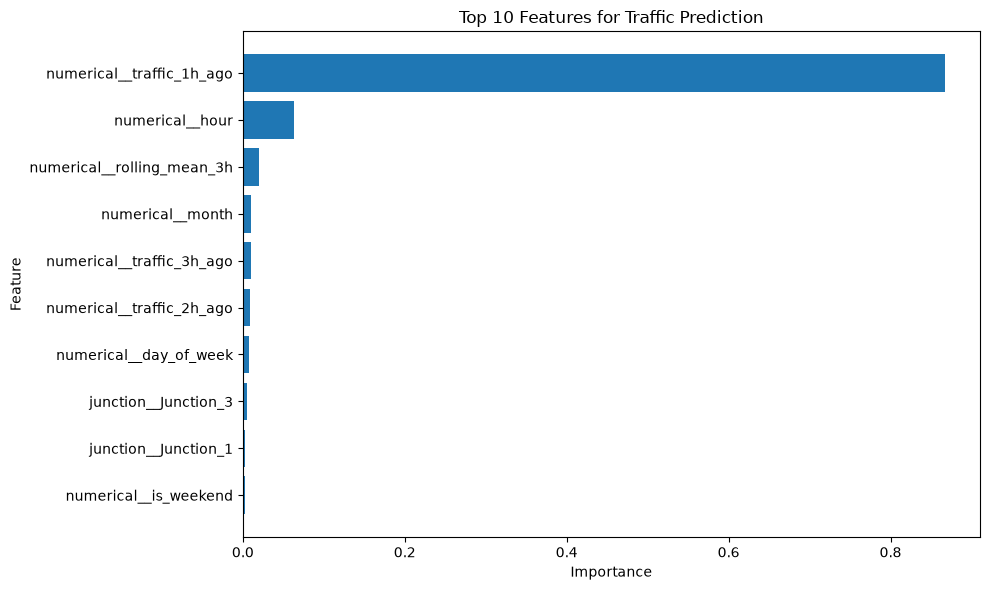

In [47]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Traffic Prediction")

plt.tight_layout()

plt.show()

In [49]:
import sys
import os

sys.path.append(os.path.abspath(".."))

print(os.path.abspath(".."))

d:\hackathon\TrafficProject\quantum-traffic-signal-optimizer


In [50]:
from src.data_preprocessing import prepare_model_data

print("Import successful!")

Import successful!


In [51]:
processed_df = prepare_model_data(
    "../data/traffic.csv"
)

print("Processed dataset shape:", processed_df.shape)

print("\nColumns:")
print(processed_df.columns.tolist())

print("\nFirst 5 rows:")
display(processed_df.head())

Processed dataset shape: (48104, 13)

Columns:
['DateTime', 'Junction', 'Vehicles', 'ID', 'hour', 'day_of_week', 'month', 'is_weekend', 'traffic_1h_ago', 'traffic_2h_ago', 'traffic_3h_ago', 'rolling_mean_3h', 'target_vehicles']

First 5 rows:


,DateTime,Junction,Vehicles,ID,hour,day_of_week,month,is_weekend,traffic_1h_ago,traffic_2h_ago,traffic_3h_ago,rolling_mean_3h,target_vehicles
0,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1,10.0,13.0,15.0,12.666667,9.0
1,2015-11-01 03:00:00,2,6,20151101032,3,6,11,1,5.0,6.0,6.0,5.666667,7.0
2,2015-11-01 03:00:00,3,1,20151101033,3,6,11,1,5.0,7.0,9.0,7.000000,2.0
3,2015-11-01 04:00:00,3,2,20151101043,4,6,11,1,1.0,5.0,7.0,4.333333,2.0
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1,7.0,10.0,13.0,10.000000,6.0


In [74]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [59]:
from src.traffic_prediction import train_model

In [60]:
model, metrics = train_model(
    "../data/traffic.csv"
)

       TRAFFIC MODEL TRAINING
Training rows : 38480
Testing rows  : 9624

Split time:
2017-03-22 17:00:00

Random Forest Results
---------------------
MAE  : 3.7194
RMSE : 6.1208
R²   : 0.9495

Model saved to:
D:\hackathon\TrafficProject\quantum-traffic-signal-optimizer\models\traffic_model.joblib


In [61]:
from src.traffic_prediction import predict_traffic

In [62]:
raw_df = pd.read_csv("../data/traffic.csv")

raw_df["DateTime"] = pd.to_datetime(raw_df["DateTime"])

raw_df = raw_df.sort_values(
    ["Junction", "DateTime"]
).reset_index(drop=True)

print(raw_df.tail())

                 DateTime  Junction  Vehicles           ID
48115 2017-06-30 19:00:00         4        11  20170630194
48116 2017-06-30 20:00:00         4        30  20170630204
48117 2017-06-30 21:00:00         4        16  20170630214
48118 2017-06-30 22:00:00         4        22  20170630224
48119 2017-06-30 23:00:00         4        12  20170630234


In [63]:
predicted_traffic = predict_traffic(
    raw_df
)

print(predicted_traffic)

{'Junction_1': {'predicted_vehicles': 70.75, 'prediction_for': '2017-07-01 00:00:00'}, 'Junction_3': {'predicted_vehicles': 30.17, 'prediction_for': '2017-07-01 00:00:00'}, 'Junction_2': {'predicted_vehicles': 28.64, 'prediction_for': '2017-07-01 00:00:00'}, 'Junction_4': {'predicted_vehicles': 20.61, 'prediction_for': '2017-07-01 00:00:00'}}


In [64]:
import os
import pandas as pd

# Make sure results directory exists
os.makedirs("../results", exist_ok=True)

# Create metrics table
metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [metrics["MAE"]],
    "RMSE": [metrics["RMSE"]],
    "R2": [metrics["R2"]]
})

# Save metrics
metrics_df.to_csv(
    "../results/model_metrics.csv",
    index=False
)

display(metrics_df)

print("Model metrics saved successfully!")

,Model,MAE,RMSE,R2
0,Random Forest,3.71943,6.120827,0.949453


Model metrics saved successfully!


In [65]:
# Save feature importance table

feature_importance.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

display(feature_importance.head(10))

Feature importance saved successfully!


,Feature,Importance
0,numerical__traffic_1h_ago,0.867165
1,numerical__hour,0.063379
2,numerical__rolling_mean_3h,0.019633
3,numerical__month,0.010662
4,numerical__traffic_3h_ago,0.010237
5,numerical__traffic_2h_ago,0.009348
6,numerical__day_of_week,0.007835
7,junction__Junction_3,0.004986
8,junction__Junction_1,0.002714
9,numerical__is_weekend,0.002313


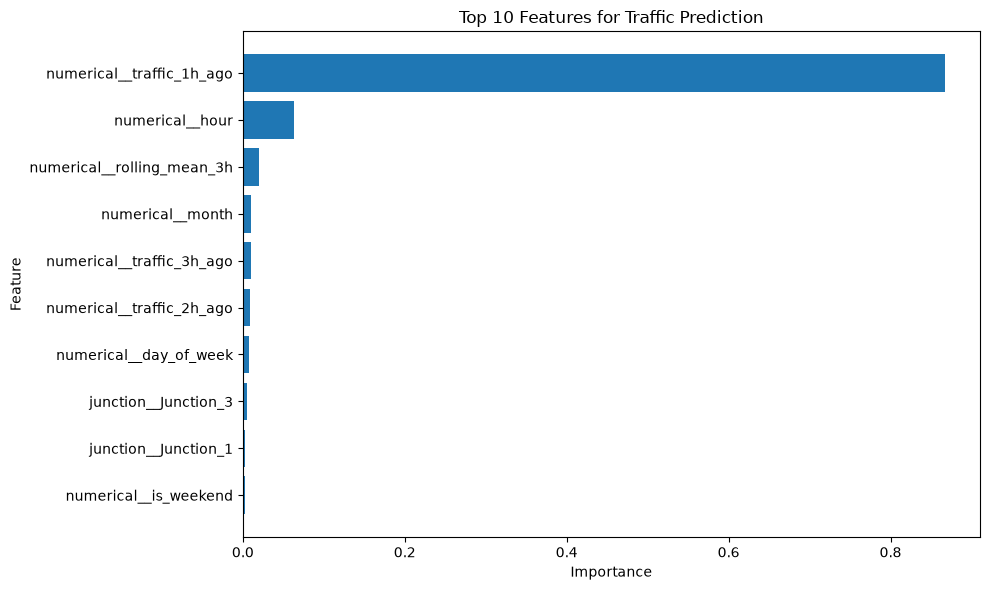

Feature importance plot saved successfully!


In [66]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Traffic Prediction")

plt.tight_layout()

plt.savefig(
    "../results/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance plot saved successfully!")

In [67]:
from src.traffic_prediction import predict_traffic

predicted_traffic = predict_traffic(
    raw_df
)

print("Predicted Traffic Demand")
print("========================")

for junction, data in predicted_traffic.items():
    print(
        f"{junction}: "
        f"{data['predicted_vehicles']} vehicles"
    )

Predicted Traffic Demand
Junction_1: 70.75 vehicles
Junction_3: 30.17 vehicles
Junction_2: 28.64 vehicles
Junction_4: 20.61 vehicles


In [68]:
traffic_demand = {
    junction: data["predicted_vehicles"]
    for junction, data in predicted_traffic.items()
}

print(traffic_demand)

{'Junction_1': 70.75, 'Junction_3': 30.17, 'Junction_2': 28.64, 'Junction_4': 20.61}


In [69]:
for junction, vehicles in traffic_demand.items():
    print(
        junction,
        "→",
        vehicles,
        "| type:",
        type(vehicles).__name__
    )

Junction_1 → 70.75 | type: float
Junction_3 → 30.17 | type: float
Junction_2 → 28.64 | type: float
Junction_4 → 20.61 | type: float


In [70]:
traffic_demand = {
    junction: data["predicted_vehicles"]
    for junction, data in predicted_traffic.items()
}

print(traffic_demand)

{'Junction_1': 70.75, 'Junction_3': 30.17, 'Junction_2': 28.64, 'Junction_4': 20.61}


In [71]:
for junction, vehicles in traffic_demand.items():
    print(
        junction,
        "→",
        vehicles,
        "| type:",
        type(vehicles).__name__
    )

Junction_1 → 70.75 | type: float
Junction_3 → 30.17 | type: float
Junction_2 → 28.64 | type: float
Junction_4 → 20.61 | type: float


In [75]:
from src.traffic_prediction import predict_traffic

In [77]:
raw_df = pd.read_csv("../data/traffic.csv")

print("Columns found in CSV:")
print(raw_df.columns.tolist())

Columns found in CSV:
['DateTime', 'Junction', 'Vehicles', 'ID']


In [78]:
for col in raw_df.columns:
    print(repr(col))

'DateTime'
'Junction'
'Vehicles'
'ID'


In [79]:
required_columns = [
    "DateTime",
    "Junction",
    "Vehicles"
]

print("Missing columns:")

for column in required_columns:
    print(column, "->", column not in raw_df.columns)

Missing columns:
DateTime -> False
Junction -> False
Vehicles -> False
